In [6]:
import os
import json
import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.models import load_model
from IPython.display import Image
from tensorflow.keras.preprocessing.image import load_img

from tensorflow.keras.layers import Conv2D, MaxPooling2D, ZeroPadding2D, Flatten, Dense ,Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import optimizers
from sklearn.metrics import classification_report, confusion_matrix

In [9]:
sns.set_style('whitegrid')
# Paths
location = '/Users/deepak/Music/dataset/data1a'
top_model_weights_path = os.path.join(location, 'top_model_weights.hdf5')
fine_tuned_model_path = location+'/ft_model.hdf5'

In [4]:
# Image Dimensions
img_width, img_height = 256, 256
batch_size = 16
nb_epoch = 50

train_data_dir = os.path.join(location, 'training')
validation_data_dir = os.path.join(location, 'validation')

In [5]:
# Count Samples
train_samples = [len(os.listdir(os.path.join(train_data_dir, i))) for i in sorted(os.listdir(train_data_dir))]
nb_train_samples = sum(train_samples)
validation_samples = [len(os.listdir(os.path.join(validation_data_dir, i))) for i in sorted(os.listdir(validation_data_dir))]
nb_validation_samples = sum(validation_samples)

In [6]:
def save_bottleneck_features(location):
    datagen = ImageDataGenerator(rescale=1. / 255)
    model = VGG16(include_top=False, weights='imagenet')

    # Train Data
    train_generator = datagen.flow_from_directory(
        train_data_dir,
        target_size=(img_width, img_height),
        batch_size=batch_size,
        class_mode=None,
        shuffle=False)

    bottleneck_train = model.predict(train_generator, steps=len(train_generator))
    np.save(os.path.join(location, 'bottleneck_features_train.npy'), bottleneck_train)

    # Validation Data
    validation_generator = datagen.flow_from_directory(
        validation_data_dir,
        target_size=(img_width, img_height),
        batch_size=batch_size,
        class_mode=None,
        shuffle=False)

    bottleneck_validation = model.predict(validation_generator, steps=len(validation_generator))
    np.save(os.path.join(location, 'bottleneck_features_validation.npy'), bottleneck_validation)

In [7]:
def train_binary_model():
    # Load Bottleneck Features
    train_data = np.load(os.path.join(location, 'bottleneck_features_train.npy'))
    validation_data = np.load(os.path.join(location, 'bottleneck_features_validation.npy'))

    # Create Labels
    train_labels = np.array([0] * train_samples[0] + [1] * train_samples[1])
    validation_labels = np.array([0] * validation_samples[0] + [1] * validation_samples[1])

    # Model Definition
    model = Sequential([
        Flatten(input_shape=train_data.shape[1:]),
        Dense(256, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

    # Model Checkpoint
    checkpoint = ModelCheckpoint(top_model_weights_path, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

    # Training
    fit = model.fit(
        train_data, train_labels,
        epochs=nb_epoch,
        batch_size=batch_size,
        validation_data=(validation_data, validation_labels),
        callbacks=[checkpoint])

    # Save Training History
    with open(os.path.join(location, 'training_history.json'), 'w') as f:
        json.dump(fit.history, f)

    return model, fit.history

In [8]:
def evaluate_model(model, directory, labels):
    datagen = ImageDataGenerator(rescale=1. / 255)
    generator = datagen.flow_from_directory(
        directory,
        target_size=(img_width, img_height),
        batch_size=batch_size,
        class_mode='binary',
        shuffle=False)

    predictions = model.predict(generator, steps=len(generator))
    pred_labels = [0 if i < 0.5 else 1 for i in predictions]

    print("\nClassification Report:\n", classification_report(labels, pred_labels))
    cm = confusion_matrix(labels, pred_labels)
    sns.heatmap(cm, annot=True, fmt='g')


In [9]:
# Save Features
save_bottleneck_features(location)


Found 1840 images belonging to 2 classes.
115/115 [==============================] - 297s 3s/step
Found 460 images belonging to 2 classes.
29/29 [==============================] - 75s 3s/step


In [10]:
# Train Model
trained_model, training_history = train_binary_model()# rmsprop, sigmoid, no regularization

Epoch 1/50
115/115 [==============================] - ETA: 0s - loss: 1.1537 - accuracy: 0.7641
Epoch 1: val_accuracy improved from -inf to 0.90870, saving model to /Users/deepak/Music/dataset/data1a\top_model_weights.hdf5


C:\Users\deepak\AppData\Local\Programs\Python\Python38\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


115/115 [==============================] - 15s 123ms/step - loss: 1.1537 - accuracy: 0.7641 - val_loss: 0.2440 - val_accuracy: 0.9087
Epoch 2/50
115/115 [==============================] - ETA: 0s - loss: 0.4817 - accuracy: 0.8473
Epoch 2: val_accuracy did not improve from 0.90870
115/115 [==============================] - 14s 125ms/step - loss: 0.4817 - accuracy: 0.8473 - val_loss: 0.3088 - val_accuracy: 0.8957
Epoch 3/50
115/115 [==============================] - ETA: 0s - loss: 0.2483 - accuracy: 0.9152
Epoch 3: val_accuracy improved from 0.90870 to 0.91522, saving model to /Users/deepak/Music/dataset/data1a\top_model_weights.hdf5
115/115 [==============================] - 13s 114ms/step - loss: 0.2483 - accuracy: 0.9152 - val_loss: 0.2307 - val_accuracy: 0.9152
Epoch 4/50
115/115 [==============================] - ETA: 0s - loss: 0.1859 - accuracy: 0.9299
Epoch 4: val_accuracy did not improve from 0.91522
115/115 [==============================] - 13s 110ms/step - loss: 0.1859 - acc

In [11]:
def plot_metrics(history, title="Training Metrics"):
    """Plots training and validation accuracy/loss."""
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy plot
    axs[0].plot(history['accuracy'], label='Train Accuracy')
    axs[0].plot(history['val_accuracy'], label='Validation Accuracy')
    axs[0].set_title(f'{title} - Accuracy')
    axs[0].set_xlabel('Epochs')
    axs[0].set_ylabel('Accuracy')
    axs[0].legend()

    # Loss plot
    axs[1].plot(history['loss'], label='Train Loss')
    axs[1].plot(history['val_loss'], label='Validation Loss')
    axs[1].set_title(f'{title} - Loss')
    axs[1].set_xlabel('Epochs')
    axs[1].set_ylabel('Loss')
    axs[1].legend()

    plt.show()

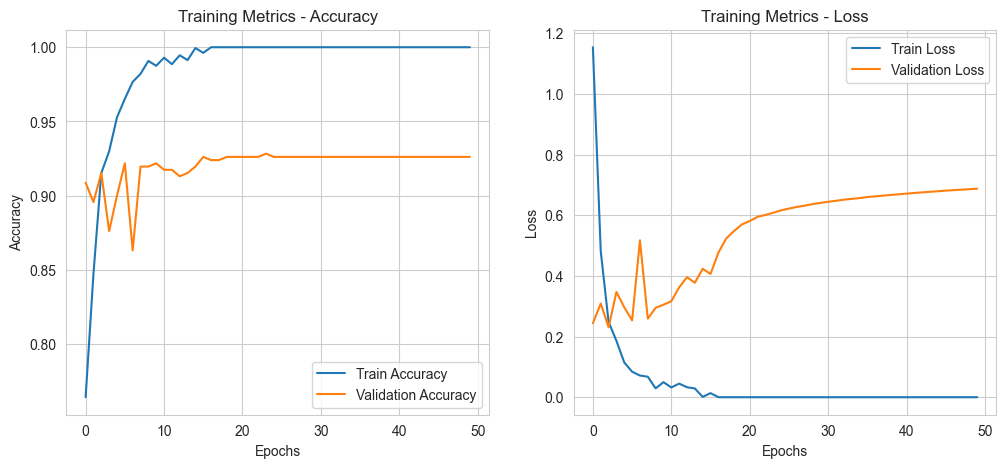

In [12]:
plot_metrics(training_history)

In [13]:
def train_binary_model2():
    train_data = np.load(os.path.join(location, 'bottleneck_features_train.npy'))
    train_labels = np.array([0] * train_samples[0] + [1] * train_samples[1])

    validation_data = np.load(os.path.join(location, 'bottleneck_features_validation.npy'))
    validation_labels = np.array([0] * validation_samples[0] + [1] * validation_samples[1])
    
    model = Sequential()
    model.add(Flatten(input_shape=train_data.shape[1:]))
    model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
    
    checkpoint = ModelCheckpoint(top_model_weights_path, monitor='val_accuracy', 
                                 verbose=2, save_best_only=True, save_weights_only=True, mode='max')

    fit = model.fit(train_data, train_labels,
              epochs=nb_epoch, batch_size=batch_size,
              validation_data=(validation_data, validation_labels),
              callbacks=[checkpoint])
    
    with open(os.path.join(location, 'top_history.txt'), 'w') as f:
        json.dump(fit.history, f)
    
    return model, fit.history

In [14]:
d1a_model2, d1a_history2 = train_binary_model2()# rmsprop, sigmoid, with l2 = 0.001

Epoch 1/50
115/115 [==============================] - ETA: 0s - loss: 1.7296 - accuracy: 0.7511
Epoch 1: val_accuracy improved from -inf to 0.87609, saving model to /Users/deepak/Music/dataset/data1a\top_model_weights.hdf5
115/115 [==============================] - 17s 147ms/step - loss: 1.7296 - accuracy: 0.7511 - val_loss: 0.4935 - val_accuracy: 0.8761
Epoch 2/50
115/115 [==============================] - ETA: 0s - loss: 0.6148 - accuracy: 0.8277
Epoch 2: val_accuracy improved from 0.87609 to 0.90217, saving model to /Users/deepak/Music/dataset/data1a\top_model_weights.hdf5
115/115 [==============================] - 15s 135ms/step - loss: 0.6148 - accuracy: 0.8277 - val_loss: 0.3514 - val_accuracy: 0.9022
Epoch 3/50
115/115 [==============================] - ETA: 0s - loss: 0.4850 - accuracy: 0.8467
Epoch 3: val_accuracy did not improve from 0.90217
115/115 [==============================] - 15s 129ms/step - loss: 0.4850 - accuracy: 0.8467 - val_loss: 0.5926 - val_accuracy: 0.7783
Ep

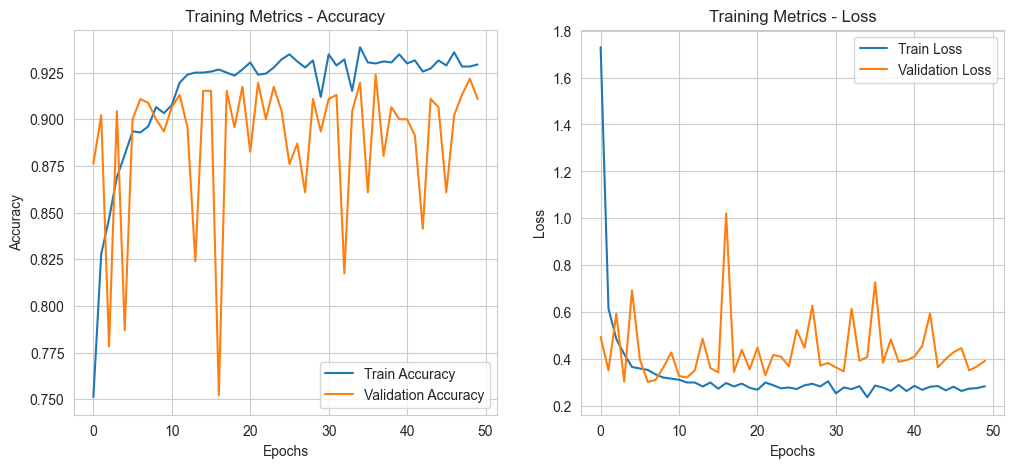

In [15]:
plot_metrics(d1a_history2)

In [24]:
def finetune_binary_model():
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

    top_model = Sequential()
    top_model.add(Flatten(input_shape=base_model.output_shape[1:]))
    top_model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.01)))
    top_model.add(Dropout(0.5))
    top_model.add(Dense(1, activation='sigmoid'))

    top_model.load_weights(top_model_weights_path)
    model = Model(inputs=base_model.input, outputs=top_model(base_model.output))
    
    for layer in model.layers[:25]:
        layer.trainable = False
    
    model.compile(loss='binary_crossentropy', optimizer=optimizers.SGD(lr=0.00001, momentum=0.9), metrics=['accuracy'])
    
    train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=40, width_shift_range=0.2, height_shift_range=0.2,
                                       shear_range=0.2, zoom_range=0.2, horizontal_flip=True, fill_mode='nearest')
    test_datagen = ImageDataGenerator(rescale=1./255)
    
    train_generator = train_datagen.flow_from_directory(train_data_dir, target_size=(img_height, img_width), batch_size=batch_size, class_mode='binary')
    validation_generator = test_datagen.flow_from_directory(validation_data_dir, target_size=(img_height, img_width), batch_size=batch_size, class_mode='binary')
    
    checkpoint = ModelCheckpoint(fine_tuned_model_path, monitor='val_accuracy', verbose=2, save_best_only=True, mode='max')
    
    fit = model.fit(train_generator, steps_per_epoch=nb_train_samples//batch_size, epochs=nb_epoch, batch_size=batch_size,
                     validation_data=validation_generator, validation_steps=nb_validation_samples//batch_size, verbose=1, callbacks=[checkpoint])
    
    with open(os.path.join(location, 'ft_history.txt'), 'w') as f:
        json.dump(fit.history, f)
    
    return model, fit.history

In [26]:
ft_model, ft_history = finetune_binary_model()

Found 1840 images belonging to 2 classes.
Found 460 images belonging to 2 classes.
Epoch 1/50
115/115 [==============================] - ETA: 0s - loss: 2.0450 - accuracy: 0.7293
Epoch 1: val_accuracy improved from -inf to 0.92188, saving model to /Users/deepak/Music/dataset/data1a\ft_model.hdf5
115/115 [==============================] - 382s 3s/step - loss: 2.0450 - accuracy: 0.7293 - val_loss: 1.2993 - val_accuracy: 0.9219
Epoch 2/50
115/115 [==============================] - ETA: 0s - loss: 1.9509 - accuracy: 0.7402
Epoch 2: val_accuracy improved from 0.92188 to 0.92634, saving model to /Users/deepak/Music/dataset/data1a\ft_model.hdf5
115/115 [==============================] - 332s 3s/step - loss: 1.9509 - accuracy: 0.7402 - val_loss: 1.2834 - val_accuracy: 0.9263
Epoch 3/50
115/115 [==============================] - ETA: 0s - loss: 2.0554 - accuracy: 0.7234
Epoch 3: val_accuracy did not improve from 0.92634
115/115 [==============================] - 350s 3s/step - loss: 2.0554 - ac

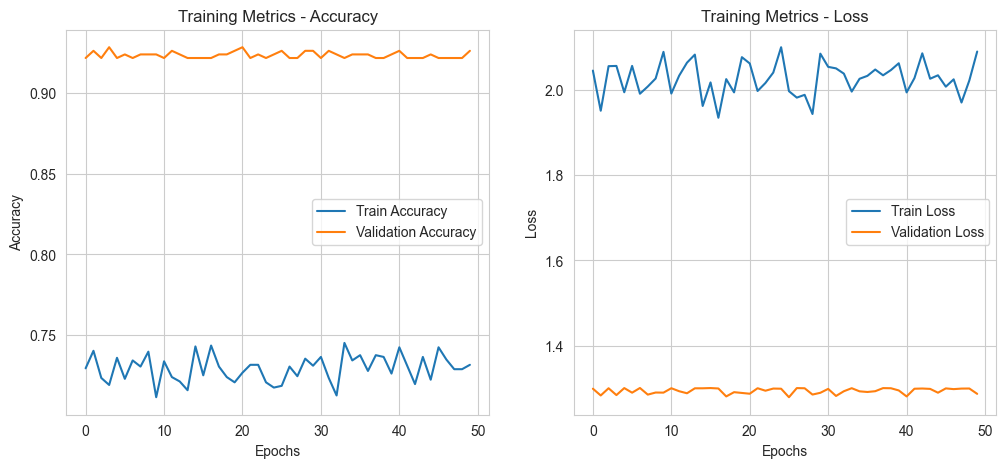

In [29]:
# WINNER
plot_metrics(ft_history) # sgd with lr = 0.0001, sigmoid, with l2 = 0.001

In [11]:
ft_model = load_model(location+'/ft_model.hdf5')

## Making Live Predictions

In [14]:
from tensorflow.keras.preprocessing.image import img_to_array


In [16]:
from urllib.request import urlretrieve

def car_categories_gate(image_path, model,option=1):
    if(option==1):
      urlretrieve(image_path, 'save.jpg')
      img = load_img('save.jpg', target_size=(256, 256))
    else:
      img = load_img(image_path, target_size=(256, 256))
    x = img_to_array(img)
    x = x.reshape((1,) + x.shape)/255
    pred = model.predict(x)
    print("Validating that damage exists...")
    print(pred)
    if pred[0][0] <=.5:

        print("Validation complete - proceed to location and severity determination")
    else:
        print("Are you sure that your car is damaged? Please submit another picture of the damage.")
        print("Hint: Try zooming in/out, using a different angle or different lighting")

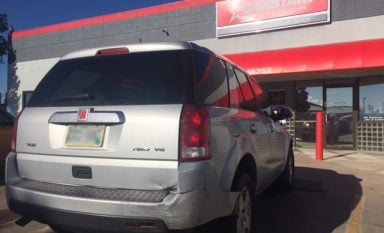

In [18]:
Image('https://www.nerdwallet.com/blog/wp-content/uploads/2015/12/exterior-car-damage-384x233.jpg')

In [20]:
car_categories_gate('https://www.nerdwallet.com/blog/wp-content/uploads/2015/12/exterior-car-damage-384x233.jpg', ft_model)

1/1 [==============================] - 2s 2s/step
Validating that damage exists...
[[0.10734023]]
Validation complete - proceed to location and severity determination
